## Interactive One-Stage Convolutional Network

This notebook demonstrates a single-stage convolutional network where you can interactively choose an input image, select different convolution kernels, and adjust parameters like kernel size, dilation, stride, and padding.

The output of the convolution is displayed live with side-by-side comaprison of two different setups.

In [5]:
import numpy as np
import tensorflow as tf
from PIL import Image
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output
import os

# Ensure TensorFlow uses eager execution for easier debugging if needed
tf.config.run_functions_eagerly(True)

print("Libraries imported successfully.")

Libraries imported successfully.


### 1. Image Selection

Choose one of the provided sample JPEG images to apply the convolution to.

In [6]:
image_files = ['/content/Sample 1.jpeg', '/content/Sample 2.jpeg']

# Check if the sample files exist
for img_file in image_files:
    if not os.path.exists(img_file):
        print(f"Warning: {img_file} not found. Please ensure it's in the /content/ directory.")

image_selector = widgets.Dropdown(
    options=image_files,
    value=image_files[0] if image_files else None,
    description='Select Image:'
)

# Global variable to store the selected image data
selected_image_data = None

def load_selected_image(change):
    global selected_image_data
    image_path = change.new
    try:
        img = Image.open(image_path).convert('L') # Convert to grayscale
        selected_image_data = np.array(img, dtype=np.float32) / 255.0 # Normalize to [0, 1]
        print(f"Loaded image: {image_path}, Shape: {selected_image_data.shape}")
    except Exception as e:
        selected_image_data = None
        print(f"Error loading image {image_path}: {e}")

image_selector.observe(load_selected_image, names='value')

# Load initial image
if image_selector.value:
    img = Image.open(image_selector.value).convert('L')
    selected_image_data = np.array(img, dtype=np.float32) / 255.0

display(image_selector)


Dropdown(description='Select Image:', options=('/content/Sample 1.jpeg', '/content/Sample 2.jpeg'), value='/co…

### 2. Define Convolution Kernels

Here are some pre-defined 3x3 kernels for various image processing effects.

In [7]:
kernels3 = {
    'Identity': np.array([[0, 0, 0],
                          [0, 1, 0],
                          [0, 0, 0]], dtype=np.float32),
    'Edge Detection (Laplacian)': np.array([[-1, -1, -1],
                                            [-1,  8, -1],
                                            [-1, -1, -1]], dtype=np.float32),
    'Sharpen': np.array([[ 0, -1,  0],
                         [-1,  5, -1],
                         [ 0, -1,  0]], dtype=np.float32),
    'Blur (Box)': np.array([[1/9, 1/9, 1/9],
                            [1/9, 1/9, 1/9],
                            [1/9, 1/9, 1/9]], dtype=np.float32),
    'Emboss': np.array([[-2, -1,  0],
                        [-1,  1,  1],
                        [ 0,  1,  2]], dtype=np.float32)
}

kernels5 = {
    'Identity': np.array([[0, 0, 0, 0, 0],
                          [0, 0, 0, 0, 0],
                          [0, 0, 1, 0, 0],
                          [0, 0, 0, 0, 0],
                          [0, 0, 0, 0, 0]], dtype=np.float32),
    'Edge Detection (Laplacian)': np.array([[-1, -1, -1, -1, -1],
                                            [-1, -1, -1, -1, -1],
                                            [-1, -1, 8, -1, -1],
                                            [-1, -1, -1, -1, -1],
                                            [-1, -1, -1, -1, -1]], dtype=np.float32),
    'Sharpen': np.array([[ 0, 0, -1, 0,  0],
                         [ 0, 0, -1, 0,  0],
                         [-1, -1, 5, -1, -1],
                         [ 0, 0, -1, 0,  0],
                         [ 0, 0, -1, 0,  0]], dtype=np.float32),
    'Blur (Box)': np.array([[1/9, 1/9, 1/9, 1/9, 1/9],
                            [1/9, 1/9, 1/9, 1/9, 1/9],
                            [1/9, 1/9, 1/9, 1/9, 1/9],
                            [1/9, 1/9, 1/9, 1/9, 1/9],
                            [1/9, 1/9, 1/9, 1/9, 1/9]], dtype=np.float32),
    'Emboss': np.array([[-2, -1, -1, 0, 0],
                        [-1, -1, 0, 0, 0],
                        [-1, 0, 1, 0,  1],
                        [ 0, 0, 0, 1, 1],
                        [ 0, 0, 1, 1, 2]], dtype=np.float32)
}

kernel_types = list(kernels3.keys())

print("Convolution kernels defined.")

Convolution kernels defined.


### 3. Convolution Function and Interactive Controls

Use the widgets below to select a kernel and adjust convolution parameters. The original and convolved images will be displayed.

In [8]:
def perform_single_convolution(image_data, kernel_type, kernel_size, dilations, strides, padding_size):
    if image_data is None:
        print("No image selected or image failed to load.")
        return None

    # Reshape image for TensorFlow: [batch, height, width, channels]
    image_tensor = tf.constant(image_data[tf.newaxis, :, :, tf.newaxis], dtype=tf.float32)

    # Get the selected kernel
    kernel = kernels3[kernel_type] if kernel_size == 3 else kernels5[kernel_type]

    # Reshape kernel for TensorFlow: [height, width, in_channels, out_channels]
    # For grayscale images, in_channels = 1, out_channels = 1
    kernel_tensor = tf.constant(kernel[:, :, tf.newaxis, tf.newaxis], dtype=tf.float32)

    # Padding configuration
    # 'VALID' means no padding, 'SAME' means padding to ensure output size is same as input (stride=1)

    if padding_size > 0:
        # Pad the image manually
        paddings = tf.constant([[0, 0], [padding_size, padding_size], [padding_size, padding_size], [0, 0]])
        image_tensor = tf.pad(image_tensor, paddings, "CONSTANT")
        padding_mode = 'VALID' # After manual padding, use VALID convolution
    else:
        padding_mode = 'VALID'

    # Apply convolution
    try:
        output_tensor = tf.nn.conv2d(
            input=image_tensor,
            filters=kernel_tensor,
            strides=[1, strides, strides, 1], # strides in height and width
            padding=padding_mode,
            dilations=[1, dilations, dilations, 1] # dilations in height and width
        )
        return output_tensor[0, :, :, 0].numpy() # Remove batch and channel dims
    except Exception as err:
        print(f"Error during convolution: {err}")
        return None


# Create widgets for interaction - Setup 1
kernel_type_widget_1 = widgets.Dropdown(
    options=kernel_types,
    value='Identity',
    description='Kernel Type 1:'
)
kernel_size_widget_1 = widgets.IntSlider(
    value=3,
    min=3,
    max=5,
    step=2,
    description='Kernel Size 1 (N x N):'
)
dilations_widget_1 = widgets.IntSlider(
    value=1,
    min=1,
    max=5,
    step=1,
    description='Dilations 1:'
)
strides_widget_1 = widgets.IntSlider(
    value=1,
    min=1,
    max=5,
    step=1,
    description='Strides 1:'
)
padding_widget_1 = widgets.IntSlider(
    value=0,
    min=0,
    max=5,
    step=1,
    description='Padding Size 1:'
)

# Create widgets for interaction - Setup 2
kernel_type_widget_2 = widgets.Dropdown(
    options=kernel_types,
    value='Edge Detection (Laplacian)', # Default to a different kernel for comparison
    description='Kernel Type 2:'
)
kernel_size_widget_2 = widgets.IntSlider(
    value=3,
    min=3,
    max=5,
    step=2,
    description='Kernel Size 2 (N x N):'
)
dilations_widget_2 = widgets.IntSlider(
    value=1,
    min=1,
    max=5,
    step=1,
    description='Dilations 2:'
)
strides_widget_2 = widgets.IntSlider(
    value=1,
    min=1,
    max=5,
    step=1,
    description='Strides 2:'
)
padding_widget_2 = widgets.IntSlider(
    value=0,
    min=0,
    max=5,
    step=1,
    description='Padding Size 2:'
)

# Link widgets to the convolution function
def interactive_convolution(
    kernel_type_1, kernel_size_1, dilations_1, strides_1, padding_size_1,
    kernel_type_2, kernel_size_2, dilations_2, strides_2, padding_size_2
):
    clear_output(wait=True)

    if selected_image_data is None:
        print("Please load an image first.")
        return

    # Perform first convolution
    output_image_data_1 = perform_single_convolution(
        selected_image_data, kernel_type_1, kernel_size_1, dilations_1, strides_1, padding_size_1
    )
    output_shape_1 = output_image_data_1.shape if output_image_data_1 is not None else "N/A"

    # For RF/ERF, the actual kernel size used is either 3 or 5
    dilated_kernel_size_1 = kernel_size_1 + (kernel_size_1 - 1) * (dilations_1 - 1)
    rf_1 = dilated_kernel_size_1
    erf_1 = dilated_kernel_size_1 # For a single layer, ERF is often approximated as RF

    # Perform second convolution
    output_image_data_2 = perform_single_convolution(
        selected_image_data, kernel_type_2, kernel_size_2, dilations_2, strides_2, padding_size_2
    )
    output_shape_2 = output_image_data_2.shape if output_image_data_2 is not None else "N/A"

    dilated_kernel_size_2 = kernel_size_2 + (kernel_size_2 - 1) * (dilations_2 - 1)
    rf_2 = dilated_kernel_size_2
    erf_2 = dilated_kernel_size_2 # For a single layer, ERF is often approximated as RF

    # Display results
    plt.figure(figsize=(14, 6)) # Increased figure height to provide more space

    # Original Image
    plt.subplot(1, 3, 1)
    plt.title('Original Image')
    plt.imshow(selected_image_data, cmap='gray')
    plt.axis('off')

    # Convolved Output 1
    plt.subplot(1, 3, 2)
    plt.title(f'Convolved Output 1 ({kernel_type_1})')
    if output_image_data_1 is not None:
        plt.imshow(output_image_data_1, cmap='gray')
    plt.axis('off')

    # Convolved Output 2
    plt.subplot(1, 3, 3)
    plt.title(f'Convolved Output 2 ({kernel_type_2})')
    if output_image_data_2 is not None:
        plt.imshow(output_image_data_2, cmap='gray')
    plt.axis('off')
    plt.tight_layout() # Adjust layout to prevent labels from overlapping
    plt.show()

    # Print the output details as text below the plot
    print("\n--- Convolution Setup 1 Details ---")
    print(f"  Output Size: {output_shape_1}")
    print(f"  RF: {rf_1}x{rf_1}")

    print("\n--- Convolution Setup 2 Details ---")
    print(f"  Output Size: {output_shape_2}")
    print(f"  RF: {rf_2}x{rf_2}")


# Combine widgets into an interactive view
ui = widgets.VBox([
    image_selector,
    widgets.HBox([
        widgets.VBox([
            widgets.Label(value='Convolution Setup 1:'),
            kernel_type_widget_1,
            kernel_size_widget_1,
            dilations_widget_1,
            strides_widget_1,
            padding_widget_1
        ]),
        widgets.VBox([
            widgets.Label(value='Convolution Setup 2:'),
            kernel_type_widget_2,
            kernel_size_widget_2,
            dilations_widget_2,
            strides_widget_2,
            padding_widget_2
        ])
    ])
])

out = widgets.interactive_output(interactive_convolution, {
    'kernel_type_1': kernel_type_widget_1,
    'kernel_size_1': kernel_size_widget_1,
    'dilations_1': dilations_widget_1,
    'strides_1': strides_widget_1,
    'padding_size_1': padding_widget_1,
    'kernel_type_2': kernel_type_widget_2,
    'kernel_size_2': kernel_size_widget_2,
    'dilations_2': dilations_widget_2,
    'strides_2': strides_widget_2,
    'padding_size_2': padding_widget_2
})

# Display the UI and output
display(ui, out)

Output()

### 4. Visualizing Convolution Mathematics (Focus on Strides)

Let's break down the mathematical operation of convolution, particularly focusing on how the `stride` parameter affects the output. Convolution involves sliding a small matrix (the kernel or filter) over the input image and computing the dot product at each position.

**Key Concepts:**
*   **Kernel/Filter:** The small matrix that slides over the input.
*   **Input Image:** The data we are convolving.
*   **Stride:** The number of pixels the kernel shifts over the input at each step. A stride of 1 means moving one pixel at a time, while a stride of 2 means moving two pixels at a time, effectively downsampling the output.
*   **Padding:** Adding extra pixels (usually zeros) around the border of the input to control the output size.

Let's consider a small example with a 3x3 input and a 2x2 kernel.

In [9]:
import numpy as np

# Small example input image (grayscale)
example_input = np.array([
    [1, 2, 3],
    [4, 5, 6],
    [7, 8, 9]
], dtype=np.float32)

# A simple 2x2 kernel
example_kernel = np.array([
    [1, 0],
    [0, 1]
], dtype=np.float32)

print("Example Input:")
print(example_input)
print("\nExample Kernel:")
print(example_kernel)

Example Input:
[[1. 2. 3.]
 [4. 5. 6.]
 [7. 8. 9.]]

Example Kernel:
[[1. 0.]
 [0. 1.]]


#### Convolution with Stride = 1

With a stride of 1, the kernel moves one pixel at a time both horizontally and vertically. Let's trace the steps:

**Input:**
```
[[1, 2, 3],
 [4, 5, 6],
 [7, 8, 9]]
```

**Kernel:**
```
[[1, 0],
 [0, 1]]
```

**Step 1: Top-left corner (0,0)**

Kernel over `[[1, 2], [4, 5]]`

Calculation: `(1*1) + (2*0) + (4*0) + (5*1) = 1 + 0 + 0 + 5 = 6`

**Step 2: Top-middle (0,1)**

Kernel over `[[2, 3], [5, 6]]`

Calculation: `(2*1) + (3*0) + (5*0) + (6*1) = 2 + 0 + 0 + 6 = 8`

**Step 3: Middle-left (1,0)**

Kernel over `[[4, 5], [7, 8]]`

Calculation: `(4*1) + (5*0) + (7*0) + (8*1) = 4 + 0 + 0 + 8 = 12`

**Step 4: Middle-right (1,1)**

Kernel over `[[5, 6], [8, 9]]`

Calculation: `(5*1) + (6*0) + (8*0) + (9*1) = 5 + 0 + 0 + 9 = 14`

**Output for Stride = 1 (VALID padding):**
```
[[ 6,  8],
 [12, 14]]
```

In [10]:
import tensorflow as tf

# Reshape input and kernel for TensorFlow conv2d
input_tensor = tf.constant(example_input[tf.newaxis, :, :, tf.newaxis], dtype=tf.float32)
kernel_tensor = tf.constant(example_kernel[:, :, tf.newaxis, tf.newaxis], dtype=tf.float32)

# Apply convolution with stride = 1
output_stride_1 = tf.nn.conv2d(
    input=input_tensor,
    filters=kernel_tensor,
    strides=[1, 1, 1, 1], # Stride 1 in height and width
    padding='VALID'
)

print("TensorFlow Output (Stride = 1):")
print(output_stride_1[0, :, :, 0].numpy())

TensorFlow Output (Stride = 1):
[[ 6.  8.]
 [12. 14.]]


#### Convolution with Stride = 2

With a stride of 2, the kernel moves two pixels at a time both horizontally and vertically. This means it skips positions, leading to a smaller output. The calculation for each step remains the same, but the starting positions of the kernel are further apart.

**Input:**
```
[[1, 2, 3],
 [4, 5, 6],
 [7, 8, 9]]
```

**Kernel:**
```
[[1, 0],
 [0, 1]]
```

**Step 1: Top-left corner (0,0)**

Kernel over `[[1, 2], [4, 5]]`

Calculation: `(1*1) + (2*0) + (4*0) + (5*1) = 1 + 0 + 0 + 5 = 6`

Since the stride is 2, the next horizontal position the kernel starts at would be `(0, 2)` (index 2). For a 2x2 kernel, this would go out of bounds of the 3x3 input. Similarly, the next vertical position would be `(2, 0)`, which also goes out of bounds for a 2x2 kernel starting there.

**Output for Stride = 2 (VALID padding):**
```
[[ 6]]
```

As you can see, increasing the stride reduces the size of the output feature map, as the kernel takes fewer steps across the input.

In [11]:
import tensorflow as tf

# Reshape input and kernel for TensorFlow conv2d
input_tensor = tf.constant(example_input[tf.newaxis, :, :, tf.newaxis], dtype=tf.float32)
kernel_tensor = tf.constant(example_kernel[:, :, tf.newaxis, tf.newaxis], dtype=tf.float32)

# Apply convolution with stride = 2
output_stride_2 = tf.nn.conv2d(
    input=input_tensor,
    filters=kernel_tensor,
    strides=[1, 2, 2, 1], # Stride 2 in height and width
    padding='VALID'
)

print("TensorFlow Output (Stride = 2):")
print(output_stride_2[0, :, :, 0].numpy())

TensorFlow Output (Stride = 2):
[[6.]]


use of MNIST data set from Gaggle


https://www.kaggle.com/datasets/hojjatk/mnist-dataset?resource=download&select=t10k-images.idx3-ubyte


other option CIFAR-10 or CIFAR-100

In [12]:
import struct
import numpy as np
import pandas as pd

# Path to the dataset file
file_path = '/content/train-images-idx3-ubyte'

try:
    with open(file_path, 'rb') as f:
        # Read the magic number, number of images, rows, and columns
        magic, num_images, num_rows, num_cols = struct.unpack('>IIII', f.read(16))

        # Ensure the magic number is correct for image files (0x00000803)
        if magic != 2051:
            raise ValueError(f"Invalid magic number: {magic}. Expected 2051 for image file.")

        # Read the image data
        # Each pixel is a byte (unsigned char, 'B'), so total bytes = num_images * num_rows * num_cols
        image_data = np.frombuffer(f.read(), dtype=np.uint8)

    # Reshape the data into individual images
    # The original data is flat, reshape to (num_images, num_rows, num_cols)
    images = image_data.reshape(num_images, num_rows, num_cols)

    print(f"Successfully loaded {num_images} images.")
    print(f"Image dimensions: {num_rows}x{num_cols} pixels.")

    # Flatten each image into a single row to create a DataFrame
    # Each row will be an image, and each column a pixel
    flattened_images = images.reshape(num_images, num_rows * num_cols)

    # Create a pandas DataFrame
    # We don't need specific column names for stats, but we can generate them if needed
    df = pd.DataFrame(flattened_images)

    print("\nDataFrame Head:")
    display(df.head())

    print("\nDataFrame Statistics:")
    display(df.describe())

except FileNotFoundError:
    print(f"Error: The file '{file_path}' was not found. Please ensure it's uploaded or in the correct directory.")
except ValueError as e:
    print(f"Data parsing error: {e}")
except Exception as e:
    print(f"An unexpected error occurred: {e}")


Successfully loaded 60000 images.
Image dimensions: 28x28 pixels.

DataFrame Head:


,0,1,2,3,4,5,6,7,8,9,...,774,775,776,777,778,779,780,781,782,783
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0



DataFrame Statistics:


,0,1,2,3,4,5,6,7,8,9,...,774,775,776,777,778,779,780,781,782,783
count,60000.0,60000.0,60000.0,60000.0,60000.0,60000.0,60000.0,60000.0,60000.0,60000.0,...,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.0000,60000.0,60000.0,60000.0,60000.0
mean,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.200433,0.088867,0.045633,0.019283,0.015117,0.0020,0.0,0.0,0.0,0.0
std,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,6.042472,3.956189,2.839845,1.686770,1.678283,0.3466,0.0,0.0,0.0,0.0
min,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.0,0.0,0.0,0.0
25%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.0,0.0,0.0,0.0
50%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.0,0.0,0.0,0.0
75%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.0,0.0,0.0,0.0
max,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,254.000000,254.000000,253.000000,253.000000,254.000000,62.0000,0.0,0.0,0.0,0.0


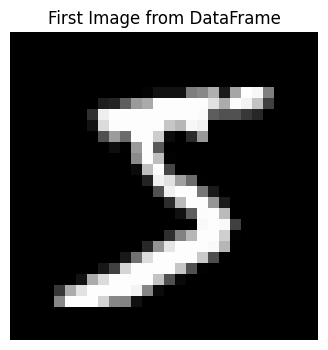

In [13]:
import matplotlib.pyplot as plt

# Get the first image (first row) from the DataFrame
first_image_flat = df.iloc[0].values

# Assuming images are 28x28 pixels, reshape the flattened image
image_dimension = int(np.sqrt(len(first_image_flat))) # Should be 28
first_image_reshaped = first_image_flat.reshape(image_dimension, image_dimension)

# Display the image
plt.figure(figsize=(4, 4))
plt.imshow(first_image_reshaped, cmap='gray')
plt.title('First Image from DataFrame')
plt.axis('off')
plt.show()

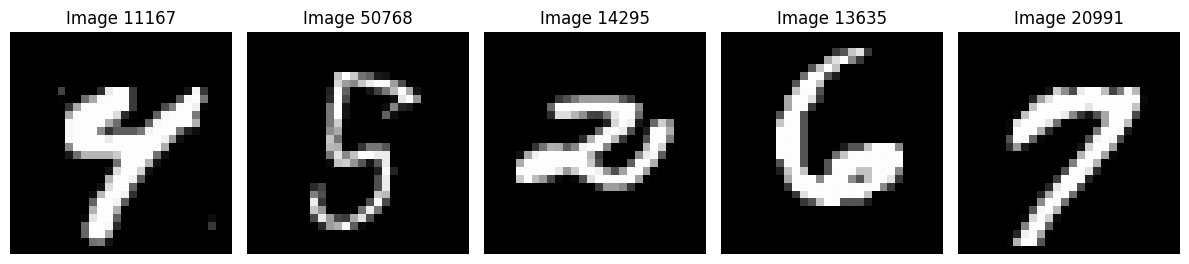

In [14]:
import matplotlib.pyplot as plt
import numpy as np

# Get 10 random indices from the DataFrame
random_indices = np.random.choice(df.index, size=5, replace=False)

# Assuming image_dimension (28) is already defined from previous cells
# If not, you might need to re-derive it: image_dimension = int(np.sqrt(df.shape[1]))
image_dimension = 28 # Given the previous context, this should be 28

plt.figure(figsize=(12, 5)) # Adjust figure size for 10 images
for i, index in enumerate(random_indices):
    # Get the flattened image data for the current random index
    random_image_flat = df.loc[index].values

    # Reshape the flattened image to its original 28x28 dimensions
    random_image_reshaped = random_image_flat.reshape(image_dimension, image_dimension)

    # Plot the image in a subplot
    plt.subplot(2, 5, i + 1) # 2 rows, 5 columns
    plt.imshow(random_image_reshaped, cmap='gray')
    plt.title(f"Image {index}")
    plt.axis('off')

plt.tight_layout() # Adjust layout to prevent overlapping titles/images
plt.show()

In [15]:
import matplotlib.pyplot as plt
import numpy as np
import ipywidgets as widgets
from IPython.display import display, clear_output

# Ensure `df` (DataFrame of MNIST images) and `image_dimension` (28) are available.
# Also, `kernels3`, `kernels5`, and `perform_single_convolution` are expected to be available globally
# from previously executed cells.

# --- Step 1: Generate 5 random images from the DataFrame and prepare selection widget ---
num_random_images = 5
# Select 5 unique random indices from the DataFrame
random_indices_for_selection = np.random.choice(df.index, size=num_random_images, replace=False)

random_image_data_dict = {}
random_image_labels = []
image_dimension = 28 # MNIST images are 28x28 pixels

for i, index in enumerate(random_indices_for_selection):
    image_flat = df.loc[index].values
    # Reshape the flattened image and normalize pixel values to [0, 1]
    image_reshaped = image_flat.reshape(image_dimension, image_dimension).astype(np.float32) / 255.0
    label = f"Random Image {i+1} (idx: {index})"
    random_image_data_dict[label] = image_reshaped # Store image data with label as key
    random_image_labels.append(label) # Store just the labels for the widget options

# Create a RadioButtons widget to allow the user to select one of these random images
image_choice_widget = widgets.RadioButtons(
    options=random_image_labels, # Pass only the labels as options
    description='Choose Image:',
    disabled=False,
    value=random_image_labels[0] # Set initial value to the label of the first random image
)

# --- Step 2: Redefine the interactive convolution function ---
# This is a modified version of the original `interactive_convolution` from cell `ac905cd3`.
# It now explicitly takes the `image_input_label` as an argument from the `image_choice_widget`.

def interactive_convolution_v2(
    image_input_label, # The selected image label (string) will be passed here
    kernel_type_1, kernel_size_1, dilations_1, strides_1, padding_size_1,
    kernel_type_2, kernel_size_2, dilations_2, strides_2, padding_size_2
):
    clear_output(wait=True) # Clear previous output in the output area

    # Retrieve the actual image data using the selected label
    image_input = random_image_data_dict.get(image_input_label)

    if image_input is None:
        print("No image selected for display. Please choose an image.")
        return

    # Perform first convolution using the provided image_input
    output_image_data_1 = perform_single_convolution(
        image_input, kernel_type_1, kernel_size_1, dilations_1, strides_1, padding_size_1
    )
    output_shape_1 = output_image_data_1.shape if output_image_data_1 is not None else "N/A"

    dilated_kernel_size_1 = kernel_size_1 + (kernel_size_1 - 1) * (dilations_1 - 1)
    rf_1 = dilated_kernel_size_1

    # Perform second convolution using the provided image_input
    output_image_data_2 = perform_single_convolution(
        image_input, kernel_type_2, kernel_size_2, dilations_2, strides_2, padding_size_2
    )
    output_shape_2 = output_image_data_2.shape if output_image_data_2 is not None else "N/A"

    dilated_kernel_size_2 = kernel_size_2 + (kernel_size_2 - 1) * (dilations_2 - 1)
    rf_2 = dilated_kernel_size_2

    # Display results using matplotlib
    plt.figure(figsize=(14, 6))

    # Original Image subplot
    plt.subplot(1, 3, 1)
    plt.title('Original Image')
    plt.imshow(image_input, cmap='gray') # Display the selected random image
    plt.axis('off')

    # Convolved Output 1 subplot
    plt.subplot(1, 3, 2)
    plt.title(f'Convolved Output 1 ({kernel_type_1})')
    if output_image_data_1 is not None:
        plt.imshow(output_image_data_1, cmap='gray')
    plt.axis('off')

    # Convolved Output 2 subplot
    plt.subplot(1, 3, 3)
    plt.title(f'Convolved Output 2 ({kernel_type_2})')
    if output_image_data_2 is not None:
        plt.imshow(output_image_data_2, cmap='gray')
    plt.axis('off')
    plt.tight_layout() # Adjust layout to prevent labels from overlapping
    plt.show()

    # Print the output details as text below the plot
    print("\n--- Convolution Setup 1 Details ---")
    print(f"  Output Size: {output_shape_1}")
    print(f"  RF: {rf_1}x{rf_1}")

    print("\n--- Convolution Setup 2 Details ---")
    print(f"  Output Size: {output_shape_2}")
    print(f"  RF: {rf_2}x{rf_2}")


# --- Step 3: Create the new UI structure and interactive output ---
# Reuse the existing convolution parameter widgets from cell `ac905cd3`.
# These are `kernel_type_widget_1`, `kernel_size_widget_1`, `dilations_widget_1`, `strides_widget_1`, `padding_widget_1`,
# and their '_2' counterparts.

new_interactive_ui = widgets.VBox([
    widgets.Label(value='Select an image from 5 random MNIST digits:'),
    image_choice_widget, # The new random image selection widget
    widgets.HBox([
        widgets.VBox([
            widgets.Label(value='Convolution Setup 1:'),
            kernel_type_widget_1,
            kernel_size_widget_1,
            dilations_widget_1,
            strides_widget_1,
            padding_widget_1
        ]),
        widgets.VBox([
            widgets.Label(value='Convolution Setup 2:'),
            kernel_type_widget_2,
            kernel_size_widget_2,
            dilations_widget_2,
            strides_widget_2,
            padding_widget_2
        ])
    ])
])

# Create a new interactive output link, connecting the new image selector
# and all existing parameter widgets to the `interactive_convolution_v2` function.
new_out = widgets.interactive_output(interactive_convolution_v2, {
    'image_input_label': image_choice_widget, # Link the new image selector here
    'kernel_type_1': kernel_type_widget_1,
    'kernel_size_1': kernel_size_widget_1,
    'dilations_1': dilations_widget_1,
    'strides_1': strides_widget_1,
    'padding_size_1': padding_widget_1,
    'kernel_type_2': kernel_type_widget_2,
    'kernel_size_2': kernel_size_widget_2,
    'dilations_2': dilations_widget_2,
    'strides_2': strides_widget_2, # Corrected from strides_2 to strides_widget_2
    'padding_size_2': padding_widget_2
})

# --- Step 4: Display the new UI and output ---
print("New Interactive Convolution Dashboard (with random MNIST image selection):")
display(new_interactive_ui, new_out)


New Interactive Convolution Dashboard (with random MNIST image selection):


Output()